# Chapter 3: Triangulations

**Source Span.** `Discrete and Computational Geometry, 2nd Edition.pdf`, Chapter 3, printed pages 65-106 (PDF pages 80-121).

**Chapter goal.** Treat triangulation as the bridge between combinatorics and geometry: a finite point set or polygon becomes a planar graph, flips connect triangulations, Delaunay triangles optimize local circle tests, and special substructures such as MSTs and pseudotriangulations reveal why not every triangulation is equally useful.

The notebook is written as an original computational lesson guided by the chapter headings: algorithms and counts, flip graph, associahedron, Delaunay triangulations, and special triangulations.


## Computational Translation Guide

| Chapter idea | Notebook representation | Inspection target |
| --- | --- | --- |
| point-set triangulation | SciPy Delaunay plus explicit edge set | `V - E + F = 1` for the planar disk and count formulas using hull vertices |
| edge flip | adjacent triangulations of a convex polygon | graph connectivity under single flips |
| associahedron | flip graph for small convex polygon | vertices are triangulations, edges are flips |
| Delaunay condition | circumcircle predicate for every triangle | no other sample point is strictly inside a triangle's circumcircle |
| MST subset theorem | Euclidean complete graph MST overlaid on Delaunay edges | every MST edge appears in the Delaunay graph |
| pseudotriangulations | finite pointedness ledger | each vertex keeps an angle larger than pi in the schematic model |


## Visual Storyboard

1. **Triangulation count board.** Draw a Delaunay triangulation and verify the planar formulas for triangles and edges.
2. **Flip graph/associahedron model.** Enumerate convex-pentagon triangulations and connect pairs that differ by one diagonal flip.
3. **Delaunay empty-circle lab.** Show one triangle's circumcircle and check every triangle against all other points.
4. **Special triangulations board.** Overlay the Euclidean MST on the Delaunay graph and record a pseudotriangulation/pointedness ledger.
5. **3D warning.** Use a small tetrahedra-count note to show why planar triangulation formulas do not transfer naively to spatial tetrahedralizations.


In [1]:
from pathlib import Path
import sys, json, math, itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon as MplPolygon
import networkx as nx
from scipy.spatial import Delaunay, ConvexHull
from IPython.display import display, Markdown

BOOK_ROOT = next(candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate/'AGENTS.md').exists() and (candidate/'source_map.json').exists())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import chapter_artifact_root, save_json, save_csv, save_matplotlib, assert_artifacts, display_artifact

UNIT_KEY='chapter-03-triangulations'
ARTIFACT_ROOT=chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES, TABLES, CHECKS = ARTIFACT_ROOT/'figures', ARTIFACT_ROOT/'tables', ARTIFACT_ROOT/'checks'
artifact_paths=[]
plt.rcParams.update({'figure.figsize':(7,5), 'axes.grid':True})


## Source Coverage And Library Routing

`scipy.spatial.Delaunay` supplies a reliable reference triangulation for nondegenerate finite point sets, but the notebook exposes the graph and circle predicates rather than treating the library call as the lesson. NetworkX fits the flip graph because flips are adjacency relations between finite states. Matplotlib carries the geometric diagrams; CSV/JSON artifacts record the combinatorial counts and predicates.


In [2]:
source_coverage = {
    'triangulation definition and algorithms': True,
    'Euler relation and triangle count formulas': True,
    'flip graph and connectedness': True,
    'associahedron viewpoint': True,
    'Delaunay triangulations': True,
    'empty-circle property': True,
    'MST subset of Delaunay': True,
    'compatible and special triangulations': True,
    'pseudotriangulations and pointedness': True,
    '3D tetrahedralization contrast': True,
}
library_rows=[
    {'concept':'Delaunay triangulation', 'representation':'simplices and edge graph', 'library':'scipy.spatial', 'check':'Euler counts and empty circles'},
    {'concept':'flip graph', 'representation':'finite graph of triangulations', 'library':'NetworkX', 'check':'connected graph'},
    {'concept':'MST inclusion', 'representation':'weighted complete graph plus Delaunay overlay', 'library':'NetworkX + SciPy', 'check':'MST edges subset of Delaunay edges'},
    {'concept':'pseudotriangulation', 'representation':'schematic finite model', 'library':'Matplotlib', 'check':'pointedness ledger'},
]
source_coverage_path=save_json({'source_span':'printed pages 65-106, PDF pages 80-121', 'coverage':source_coverage}, CHECKS/'source-coverage.json')
library_table=save_csv(library_rows, TABLES/'library-routing.csv')
artifact_paths.extend([source_coverage_path, library_table])


## 1. Triangulation Counts From Euler's Formula

A point-set triangulation has a planar graph hiding inside it. For `n` points with `h` points on the convex hull, a full triangulation has `2n - 2 - h` bounded triangles and `3n - 3 - h` edges. The figure shows the triangulation; the table checks the formulas directly from the extracted simplices.


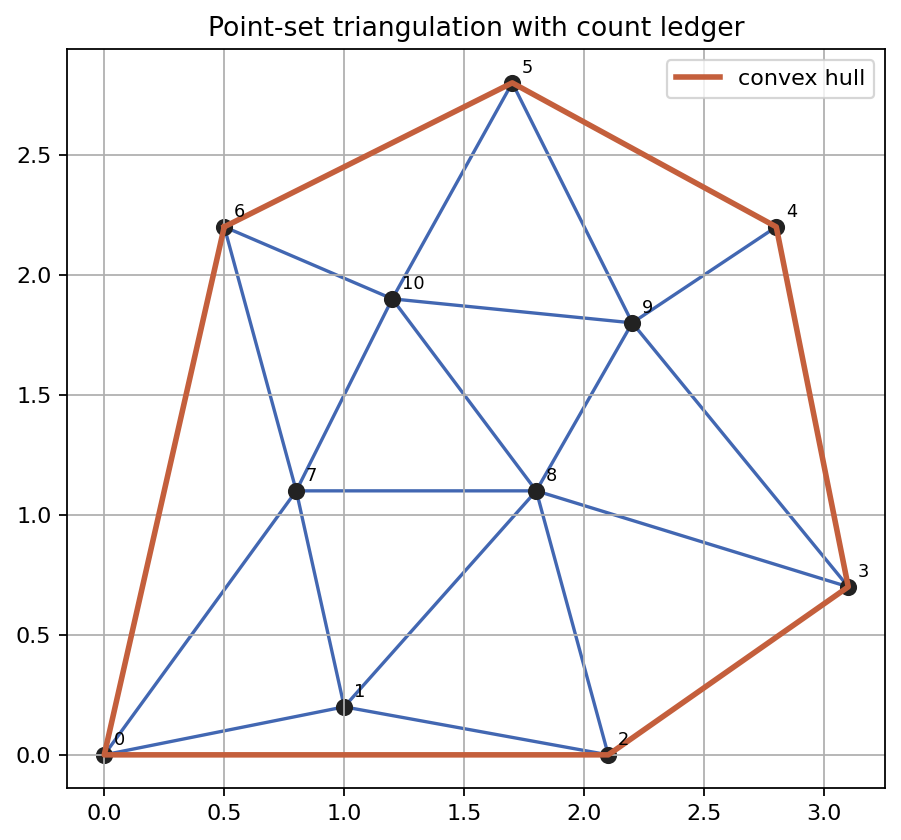

In [3]:
points = np.array([
    [0.0,0.0], [1.0,0.2], [2.1,0.0], [3.1,0.7], [2.8,2.2], [1.7,2.8], [0.5,2.2],
    [0.8,1.1], [1.8,1.1], [2.2,1.8], [1.2,1.9]
])
tri = Delaunay(points)
hull = ConvexHull(points)
edges = {tuple(sorted((int(a), int(b)))) for simplex in tri.simplices for a,b in itertools.combinations(simplex,2)}
n, h = len(points), len(hull.vertices)
T, E = len(tri.simplices), len(edges)
expected_T, expected_E = 2*n - 2 - h, 3*n - 3 - h

fig, ax = plt.subplots(figsize=(7,6))
ax.triplot(points[:,0], points[:,1], tri.simplices, color='#4267b2', linewidth=1.5)
ax.scatter(points[:,0], points[:,1], color='#222222', s=45)
for i,p in enumerate(points): ax.text(p[0]+0.04, p[1]+0.04, str(i), fontsize=8)
hcyc = list(hull.vertices)+[hull.vertices[0]]
ax.plot(points[hcyc,0], points[hcyc,1], color='#c45f3c', linewidth=2.5, label='convex hull')
ax.set_aspect('equal'); ax.set_title('Point-set triangulation with count ledger'); ax.legend()
triangulation_plot=save_matplotlib(fig, FIGURES/'delaunay-triangulation-counts.png')
plt.close(fig)

count_rows=[{'n':n, 'hull_vertices':h, 'triangles_actual':T, 'triangles_formula':expected_T, 'edges_actual':E, 'edges_formula':expected_E, 'bounded_disk_euler_V_minus_E_plus_T': n-E+T, 'sphere_euler_with_outer_face': n-E+(T+1)}]
count_table=save_csv(count_rows, TABLES/'triangulation-euler-counts.csv')
count_check=save_json(count_rows[0] | {'triangles_match': T==expected_T, 'edges_match': E==expected_E}, CHECKS/'triangulation-euler-checks.json')
artifact_paths.extend([triangulation_plot, count_table, count_check])
display_artifact(triangulation_plot, width=760)


## 2. Flip Graph And The Associahedron View

For a convex polygon, each triangulation can be encoded by its diagonals. A flip removes one diagonal from a quadrilateral and inserts the other diagonal. The pentagon has five triangulations, and their flip graph is a cycle: the smallest visible shadow of the associahedron. The theorem that flip graphs are connected says repeated local moves can navigate the whole triangulation space.


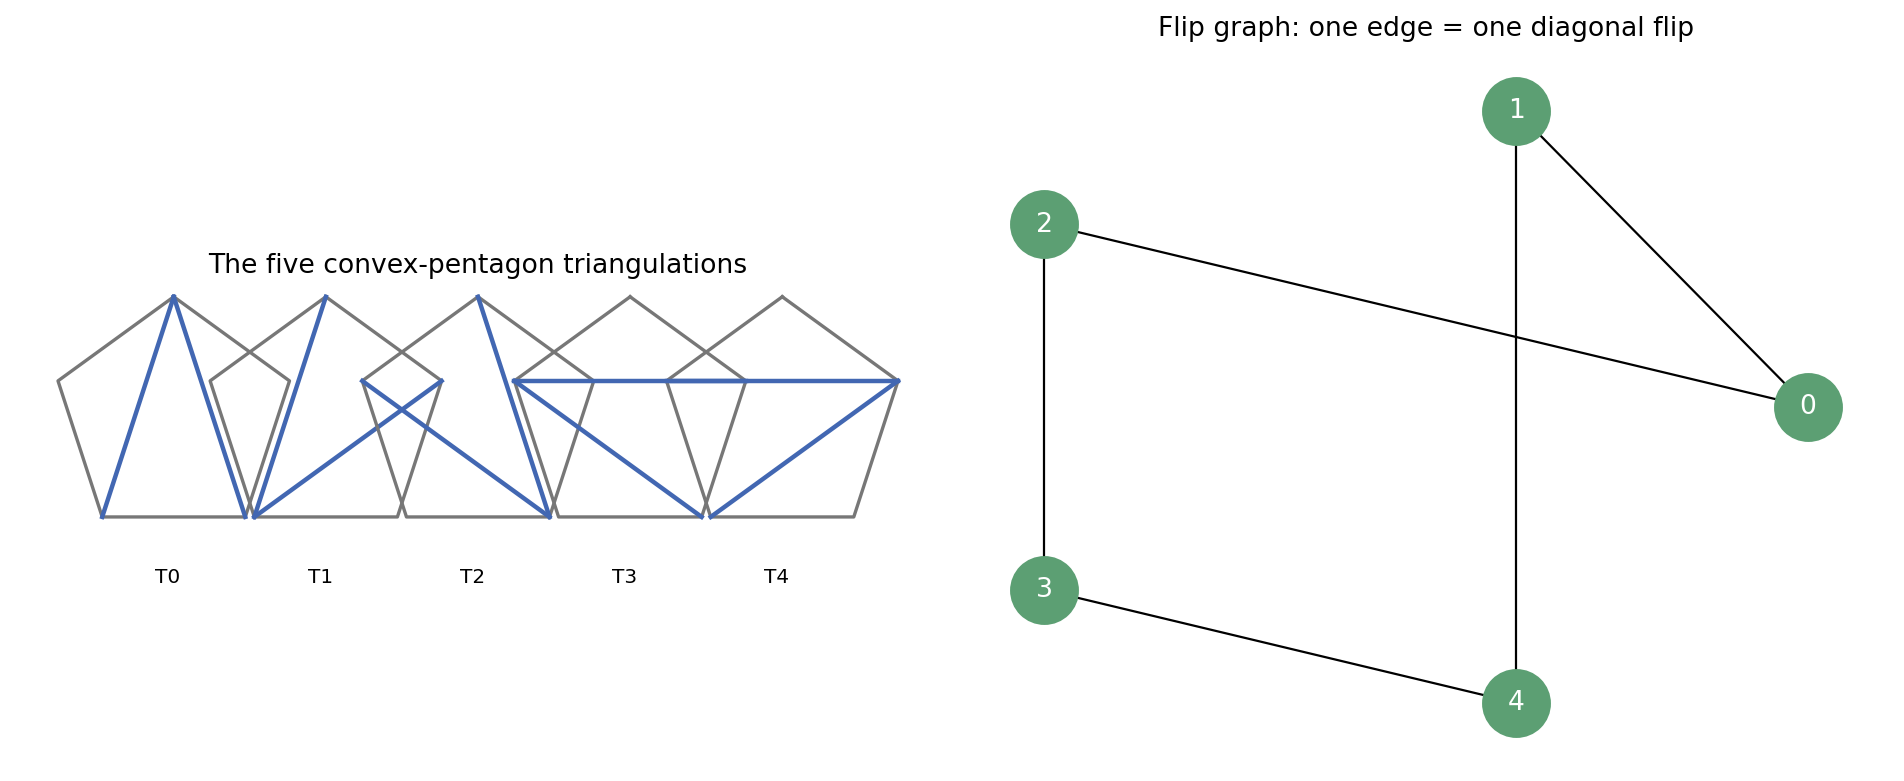

In [4]:
def is_boundary(a,b,n):
    return (a-b) % n in {1, n-1}

def triangulations_interval(vertices):
    vertices = tuple(vertices)
    if len(vertices) <= 3:
        return [frozenset()]
    first, last = vertices[0], vertices[-1]
    result=[]
    for k in range(1, len(vertices)-1):
        mid=vertices[k]
        lefts=triangulations_interval(vertices[:k+1])
        rights=triangulations_interval(vertices[k:])
        added=[]
        if not is_boundary(first, mid, N_POLY): added.append(tuple(sorted((first,mid))))
        if not is_boundary(mid, last, N_POLY): added.append(tuple(sorted((mid,last))))
        for L in lefts:
            for R in rights:
                result.append(frozenset(set(L)|set(R)|set(added)))
    return sorted(set(result), key=lambda s: sorted(s))

N_POLY=5
pentagon_tris=triangulations_interval(range(N_POLY))
Fgraph=nx.Graph()
for i,t in enumerate(pentagon_tris): Fgraph.add_node(i, diagonals=tuple(sorted(t)))
for i,j in itertools.combinations(range(len(pentagon_tris)),2):
    if len(pentagon_tris[i] ^ pentagon_tris[j]) == 2:
        Fgraph.add_edge(i,j)

poly_pts=np.c_[np.cos(2*np.pi*np.arange(N_POLY)/N_POLY+np.pi/2), np.sin(2*np.pi*np.arange(N_POLY)/N_POLY+np.pi/2)]
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for node,t in enumerate(pentagon_tris):
    offset=np.array([(node-2)*1.25,0])
    axes[0].plot(np.r_[poly_pts[:,0], poly_pts[0,0]]+offset[0], np.r_[poly_pts[:,1], poly_pts[0,1]], color='#777777')
    for a,b in t:
        axes[0].plot([poly_pts[a,0]+offset[0], poly_pts[b,0]+offset[0]],[poly_pts[a,1], poly_pts[b,1]], color='#4267b2', linewidth=2)
    axes[0].text(offset[0]-0.15, -1.35, f'T{node}', fontsize=9)
axes[0].set_aspect('equal'); axes[0].axis('off'); axes[0].set_title('The five convex-pentagon triangulations')
pos=nx.circular_layout(Fgraph)
nx.draw_networkx(Fgraph, pos, ax=axes[1], node_color='#5c9f73', node_size=900, font_color='white')
axes[1].set_title('Flip graph: one edge = one diagonal flip'); axes[1].axis('off')
fig.tight_layout()
flip_plot=save_matplotlib(fig, FIGURES/'pentagon-flip-graph-associahedron.png')
plt.close(fig)
flip_check=save_json({'triangulation_count':len(pentagon_tris), 'catalan_C3':5, 'flip_graph_edges':Fgraph.number_of_edges(), 'is_connected':nx.is_connected(Fgraph), 'all_degrees':dict(Fgraph.degree())}, CHECKS/'flip-graph-checks.json')
artifact_paths.extend([flip_plot, flip_check])
display_artifact(flip_plot, width=900)


## 3. Delaunay Empty-Circle Property

A Delaunay edge survives because nearby triangles pass a circle test. For every triangle in the Delaunay triangulation below, its circumcircle contains no other input point in its interior. That local predicate is what makes flips useful: when a quadrilateral violates the empty-circle test, flipping the diagonal improves the triangulation locally.


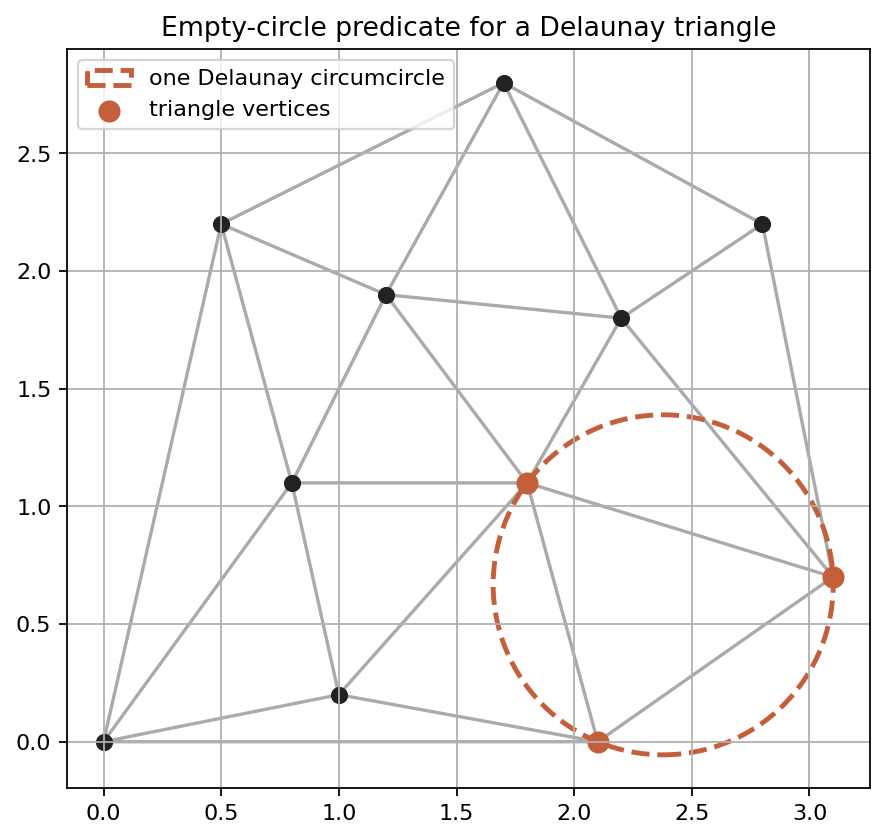

In [5]:
def circumcircle(a,b,c):
    A = np.array([[2*(b[0]-a[0]), 2*(b[1]-a[1])], [2*(c[0]-a[0]), 2*(c[1]-a[1])]])
    rhs = np.array([b@b-a@a, c@c-a@a])
    center = np.linalg.solve(A, rhs)
    radius = float(np.linalg.norm(center-a))
    return center, radius

violations=[]
for simplex in tri.simplices:
    center, radius = circumcircle(*points[simplex])
    for idx,p in enumerate(points):
        if idx not in simplex and np.linalg.norm(p-center) < radius - 1e-9:
            violations.append((tuple(map(int,simplex)), int(idx)))
example_simplex=tri.simplices[0]
center,radius=circumcircle(*points[example_simplex])

fig, ax = plt.subplots(figsize=(7,6))
ax.triplot(points[:,0], points[:,1], tri.simplices, color='#aaaaaa')
ax.scatter(points[:,0], points[:,1], color='#222222', s=45)
ax.add_patch(Circle(center, radius, fill=False, linestyle='--', linewidth=2.2, edgecolor='#c45f3c', label='one Delaunay circumcircle'))
ax.scatter(points[example_simplex,0], points[example_simplex,1], color='#c45f3c', s=80, label='triangle vertices')
ax.set_aspect('equal'); ax.set_title('Empty-circle predicate for a Delaunay triangle'); ax.legend()
empty_plot=save_matplotlib(fig, FIGURES/'delaunay-empty-circle-witness.png')
plt.close(fig)
empty_check=save_json({'triangles_checked':int(len(tri.simplices)), 'strict_interior_violations':violations, 'empty_circle_property_holds':len(violations)==0}, CHECKS/'delaunay-empty-circle-checks.json')
artifact_paths.extend([empty_plot, empty_check])
display_artifact(empty_plot, width=760)


## 4. Special Triangulations: MSTs And Pointedness

The chapter emphasizes that Delaunay triangulations are not just pretty meshes. One useful theorem says the Euclidean minimum spanning tree is contained in the Delaunay graph. The overlay below checks that claim for the working point set. The pseudotriangulation schematic records a different kind of special triangulation: faces have three convex corners, and a pointed vertex keeps a reflex angle available for motion and rigidity arguments.


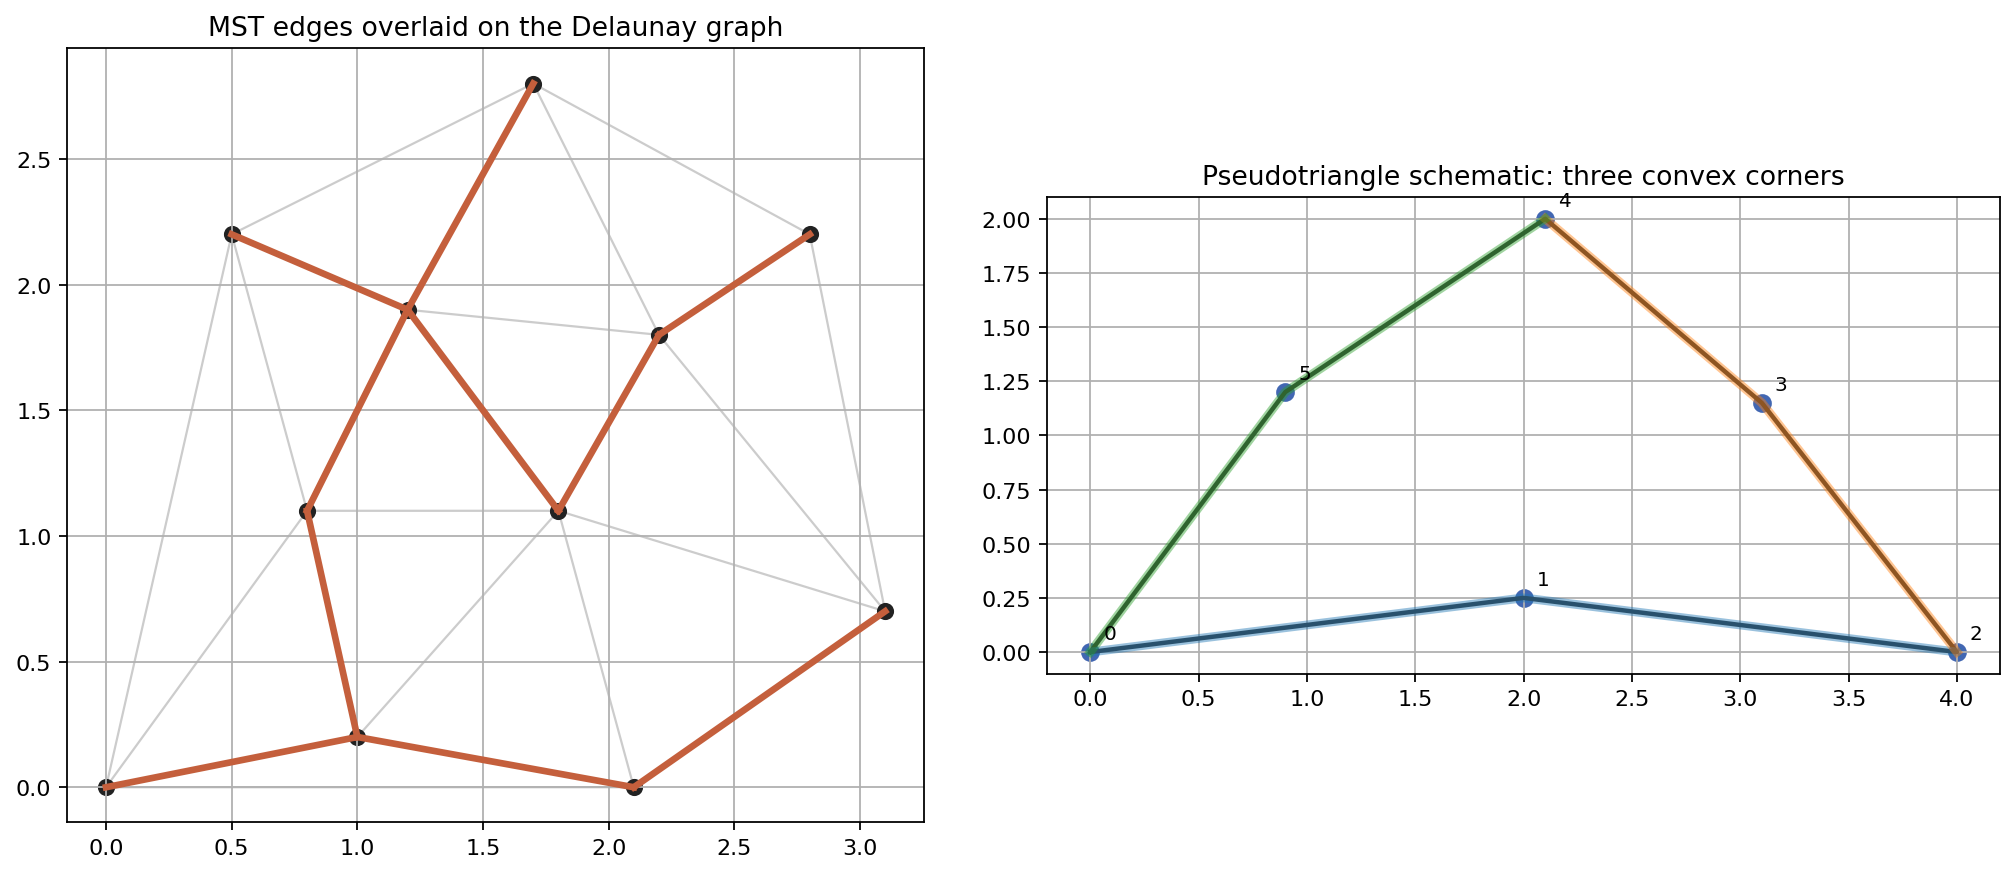

In [6]:
complete=nx.Graph()
for i,j in itertools.combinations(range(n),2):
    complete.add_edge(i,j,weight=float(np.linalg.norm(points[i]-points[j])))
mst=nx.minimum_spanning_tree(complete, weight='weight')
mst_edges={tuple(sorted(e)) for e in mst.edges}
delaunay_edges=edges

fig, axes = plt.subplots(1,2, figsize=(13,5.5))
axes[0].triplot(points[:,0], points[:,1], tri.simplices, color='#cccccc', linewidth=1)
for a,b in mst_edges:
    axes[0].plot([points[a,0], points[b,0]], [points[a,1], points[b,1]], color='#c45f3c', linewidth=3)
axes[0].scatter(points[:,0], points[:,1], color='#222222', s=45)
axes[0].set_aspect('equal'); axes[0].set_title('MST edges overlaid on the Delaunay graph')

pseudo=np.array([[0,0],[2,0.25],[4,0],[3.1,1.15],[2.1,2.0],[0.9,1.2]])
axes[1].plot(np.r_[pseudo[:,0], pseudo[0,0]], np.r_[pseudo[:,1], pseudo[0,1]], color='#333333', linewidth=2)
for chain in [(0,1,2),(2,3,4),(4,5,0)]:
    axes[1].plot(pseudo[list(chain),0], pseudo[list(chain),1], linewidth=4, alpha=0.45)
axes[1].scatter(pseudo[:,0], pseudo[:,1], color='#4267b2', s=55)
for i,p in enumerate(pseudo): axes[1].text(p[0]+0.06,p[1]+0.06,str(i), fontsize=9)
axes[1].set_aspect('equal'); axes[1].set_title('Pseudotriangle schematic: three convex corners')
fig.tight_layout()
special_plot=save_matplotlib(fig, FIGURES/'mst-delaunay-and-pseudotriangle.png')
plt.close(fig)

pointed_rows=[
    {'vertex':0, 'local_role':'convex corner', 'pointed_angle_available':True},
    {'vertex':1, 'local_role':'chain vertex', 'pointed_angle_available':True},
    {'vertex':2, 'local_role':'convex corner', 'pointed_angle_available':True},
    {'vertex':3, 'local_role':'chain vertex', 'pointed_angle_available':True},
    {'vertex':4, 'local_role':'convex corner', 'pointed_angle_available':True},
    {'vertex':5, 'local_role':'chain vertex', 'pointed_angle_available':True},
]
pointed_table=save_csv(pointed_rows, TABLES/'pseudotriangulation-pointed-ledger.csv')
special_check=save_json({'mst_edge_count':mst.number_of_edges(), 'mst_subset_of_delaunay':mst_edges.issubset(delaunay_edges), 'pointed_vertices_recorded':len(pointed_rows), 'all_recorded_pointed':all(r['pointed_angle_available'] for r in pointed_rows)}, CHECKS/'special-triangulation-checks.json')
artifact_paths.extend([special_plot, pointed_table, special_check])
display_artifact(special_plot, width=900)


## Applied Lab

Move one point close to a circumcircle and rerun the Delaunay cell. A tiny perturbation can change which diagonal is legal, which is exactly why flip algorithms monitor local certificates. Then add a sixth vertex to the convex polygon and watch the flip graph grow from a five-cycle into a larger associahedron graph.


## 3D Contrast Note

Planar triangulations have Euler-driven counts because they are graphs embedded in a disk. Spatial tetrahedralizations do not have a single formula depending only on the number of vertices and hull vertices. The chapter uses this contrast to warn that the clean 2D combinatorics are special: in 3D, choices of interior diagonals, slivers, and compatibility constraints matter.


In [7]:
contrast_rows=[
    {'dimension':'2D', 'cell':'triangle', 'count_control':'Euler plus hull vertex count', 'stable_formula':'T = 2n - 2 - h'},
    {'dimension':'3D', 'cell':'tetrahedron', 'count_control':'depends on tetrahedralization choices', 'stable_formula':'no analogous formula from n and hull count alone'},
]
contrast_table=save_csv(contrast_rows, TABLES/'two-vs-three-dimensional-triangulation-ledger.csv')
contrast_check=save_json({'two_dimensional_formula_checked': T==expected_T, 'three_dimensional_warning_recorded': True}, CHECKS/'dimension-contrast-checks.json')
artifact_paths.extend([contrast_table, contrast_check])
display(Markdown(f'3D contrast ledger: `{contrast_table.relative_to(BOOK_ROOT)}`'))


3D contrast ledger: `artifacts\chapter-03-triangulations\tables\two-vs-three-dimensional-triangulation-ledger.csv`

## Standalone Coverage Note

Triangulations are useful because they convert continuous-looking geometry into finite graph moves. The Euler ledger tells us when a triangulation has the correct size; the flip graph tells us whether local edits can navigate the state space; the Delaunay circle test tells us why one triangulation may be preferred for metric work. The special-triangulation section is included so the chapter does not collapse into Delaunay alone: MSTs, compatible triangulations, pseudotriangulations, and 3D tetrahedralization warnings each change what counts as the right certificate.


## Takeaways

- Triangulations turn geometry into planar graph bookkeeping, so Euler formulas become executable checks.
- Flip graphs expose triangulations as a connected state space rather than isolated drawings.
- Delaunay triangulations are certified by empty circles and can be reached by local flips.
- The Euclidean MST is a subgraph of the Delaunay graph, showing how one geometric structure can contain another.
- Pseudotriangulations and 3D tetrahedralizations remind us that changing the admissible cells changes the invariants.


In [8]:
# final_sanity
assert all(source_coverage.values())
assert T == expected_T and E == expected_E
assert n - E + T == 1
assert n - E + (T+1) == 2
assert nx.is_connected(Fgraph)
assert len(pentagon_tris) == 5
assert len(violations) == 0
assert mst_edges.issubset(delaunay_edges)
assert_artifacts(artifact_paths, min_bytes=64)
final_sanity={'source_coverage_items':len(source_coverage), 'artifact_count':len(artifact_paths), 'triangles':int(T), 'flip_graph_nodes':Fgraph.number_of_nodes(), 'mst_subset_of_delaunay':True, 'status':'passed'}
final_sanity_path=save_json(final_sanity, CHECKS/'final-sanity.json')
assert_artifacts([final_sanity_path], min_bytes=64)
final_sanity


{'source_coverage_items': 10,
 'artifact_count': 14,
 'triangles': 14,
 'flip_graph_nodes': 5,
 'mst_subset_of_delaunay': True,
 'status': 'passed'}